# 1. Carregar Imagem

# Teste Sobel

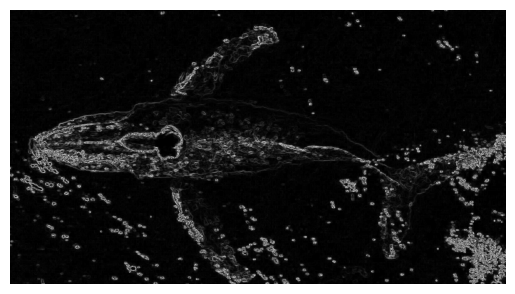

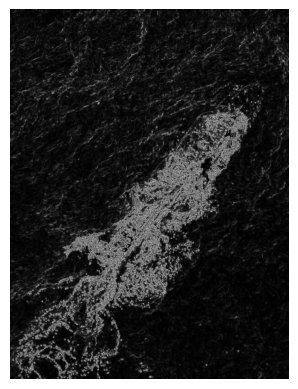

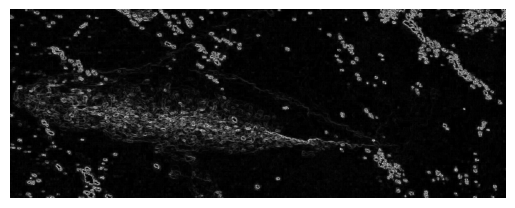

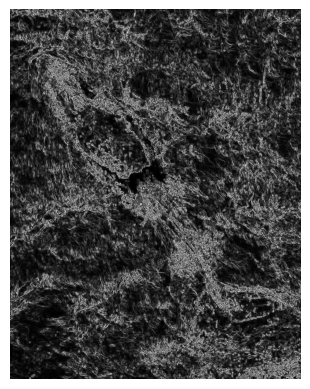

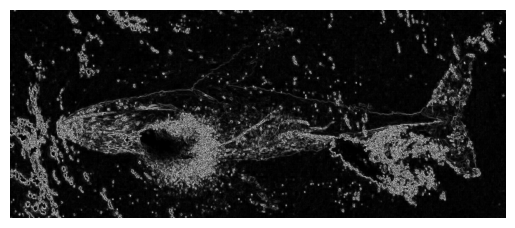

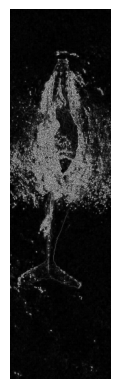

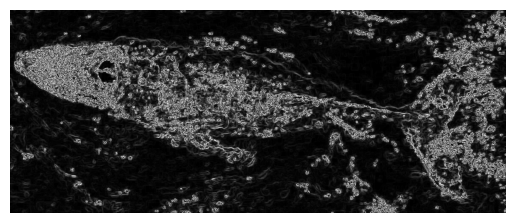

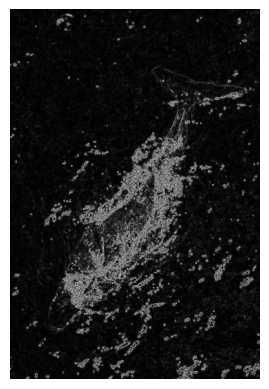

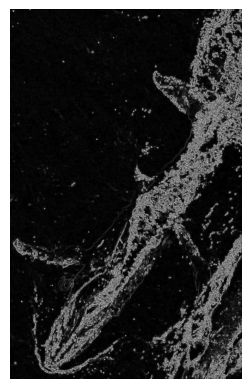

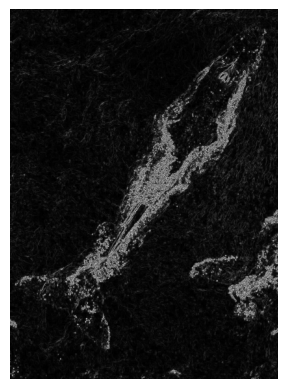

In [3]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Caminho da pasta
pasta = "Teste_Frames"
pasta_saida = "Resultados_Teste"

# Percorre todos os arquivos da pasta
for arquivo in os.listdir(pasta):
    caminho_imagem = os.path.join(pasta, arquivo)

    # Verifica se é imagem
    if not (arquivo.endswith(".png") or arquivo.endswith(".jpg") or arquivo.endswith(".jpeg")):
        continue

    # Carrega a imagem
    img = cv2.imread(caminho_imagem)
    if img is None:
        continue

    # Pré-processamento
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Aplicar o filtro Sobel para bordas horizontais (dx=0, dy=1) e verticais (dx=1, dy=0)
    # cv2.CV_64F permite valores negativos para não perder bordas pretas/brancas
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # 3. Calcular a magnitude do gradiente (combinar x e y)
    sobel_final = cv2.magnitude(sobelx, sobely)

    # 4. Converter de volta para 8-bits e exibir
    sobel_final = np.uint8(np.absolute(sobel_final))

    # Exibir a imagem
    plt.imshow(sobel_final, cmap='gray')
    plt.axis('off') # Ocultar eixos
    plt.show()

# 2. Converter em tons de cinza

# 3. Pré-Processamento

# 4. Realce de bordas

# 5. Detectar cauda

# 6. Pós-processamento

In [17]:
import cv2
import numpy as np
import os

# Caminho da pasta
pasta = "Frames_Teste"
pasta_saida = "Resultados_Teste"

# Percorre todos os arquivos da pasta
for arquivo in os.listdir(pasta):
    caminho_imagem = os.path.join(pasta, arquivo)

    # Verifica se é imagem
    if not (arquivo.endswith(".png") or arquivo.endswith(".jpg") or arquivo.endswith(".jpeg")):
        continue

    # Carrega a imagem
    img = cv2.imread(caminho_imagem)
    if img is None:
        continue

    # Pré-processamento
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)

     # 👉 SALVA O RESULTADO DO PRÉ-PROCESSAMENTO
    nome_base = os.path.splitext(arquivo)[0]
    cv2.imwrite(os.path.join(pasta_saida, f"{nome_base}_edges.jpg"), edges)

    # Encontra contornos
    contornos, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contornos:
        # Aproxima o contorno para um polígono
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.04 * peri, True)

        # Se tiver 3 vértices, é um triângulo
        if len(approx) == 3:
            cv2.drawContours(img, [approx], -1, (0, 255, 0), 3)

    # Salva imagem com mesmo nome na pasta de saída
    caminho_saida = os.path.join(pasta_saida, arquivo)
    cv2.imwrite(caminho_saida, img)
    print("Processamento concluído. Imagens salvas em:", pasta_saida)

Processamento concluído. Imagens salvas em: Resultados_Teste
Processamento concluído. Imagens salvas em: Resultados_Teste
Processamento concluído. Imagens salvas em: Resultados_Teste
Processamento concluído. Imagens salvas em: Resultados_Teste
Processamento concluído. Imagens salvas em: Resultados_Teste
Processamento concluído. Imagens salvas em: Resultados_Teste
Processamento concluído. Imagens salvas em: Resultados_Teste
Processamento concluído. Imagens salvas em: Resultados_Teste
Processamento concluído. Imagens salvas em: Resultados_Teste
Processamento concluído. Imagens salvas em: Resultados_Teste
